In [1]:
import numpy as np
import pandas as pd
import h5py

from SushiLife import *

In [6]:
f = h5py.File("../../../../data/stock_info.hdf5", "r")
array_stock, axis_stock = load_data(f, "stock", chunks=5, in_memory=False)
array_value, axis_value = load_data(f, "value", chunks=5, in_memory=False)

data_stock = DataAsset(array_stock, axis_stock, chunks=5)
data_value = DataAsset(array_value, axis_value, chunks=5)

# with pandas dataframe

In [8]:
%%time
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=True)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=True)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트
columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
           "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    fin_stat = data_value.get_info(updater._date, num=2,
                                   fields=columns)

    df = pd.DataFrame(fin_stat[-2], index=data_value.codes, columns=columns)
    df = df[~np.isnan(df["상장시가총액(원)"])]  # 상장종목 고려
    df = df.sort_values(by=['상장시가총액(원)']).iloc[:int(len(df.index) * 0.3)]  # 소형주

    # 종목선정
    df["PER"] = df["상장시가총액(원)"] / df["지배주주순이익(원)(직전4분기)"]
    df["PBR"] = df["상장시가총액(원)"] / df["지배주주지분(원)"]
    df["PCR"] = df["상장시가총액(원)"] / df["현금흐름(원)(직전4분기)"]
    df["PSR"] = df["상장시가총액(원)"] / df["매출액(원)(직전4분기)"]

    df = df[df["PER"] > 0]
    df = df[df["PBR"] > 0]
    df = df[df["PCR"] > 0]
    df = df[df["PSR"] > 0]

    df["Rank"] = (df["PER"].rank() + df["PBR"].rank() + df["PCR"].rank() + df["PSR"].rank()).rank()

    df = df[df["Rank"] < 51]

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    매수종목 = np.sort(df.index)
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)

    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량, 주문종류="조건부지정가")
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        if not np.isnan(현재가[i]):
            매수수량 = int(agent.total_balance / 50 / 현재가[i])
            agent.buy("stock", 종목코드, 현재가[i], 매수수량, 주문종류="조건부지정가")
        i += 1

    for i in range(21):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

매수 체결 :  A000420 체결가 :  2530.0 주문수량 :  790
매수 체결 :  A000590 체결가 :  22800.0 주문수량 :  87
매수 체결 :  A001070 체결가 :  13550.0 주문수량 :  147
매수 체결 :  A001600 체결가 :  4260.0 주문수량 :  469
매수 체결 :  A001950 체결가 :  5660.0 주문수량 :  353
매수 체결 :  A002050 체결가 :  3810.0 주문수량 :  524
매수 체결 :  A002290 체결가 :  7020.0 주문수량 :  284
매수 체결 :  A002360 체결가 :  3460.0 주문수량 :  578
매수 실패 :  A003280 주문가 7950.0 주문수량 :  251
매수 체결 :  A003650 체결가 :  9250.0 주문수량 :  216
매수 체결 :  A004090 체결가 :  13550.0 주문수량 :  147
매수 체결 :  A004380 체결가 :  1650.0 주문수량 :  1212
매수 체결 :  A004780 체결가 :  6350.0 주문수량 :  314
매수 체결 :  A005030 체결가 :  10450.0 주문수량 :  191
매수 체결 :  A005160 체결가 :  3980.0 주문수량 :  502
매수 체결 :  A005320 체결가 :  6750.0 주문수량 :  296
매수 체결 :  A005390 체결가 :  3180.0 주문수량 :  628
매수 체결 :  A005670 체결가 :  18200.0 주문수량 :  109
매수 체결 :  A005750 체결가 :  9150.0 주문수량 :  218
매수 실패 :  A005770 주문가 500.0 주문수량 :  4000
매수 체결 :  A005820 체결가 :  6220.0 주문수량 :  321
매수 체결 :  A006730 체결가 :  11600.0 주문수량 :  172
매수 체결 :  A007160 체결가 :  3340.0 주문수량 :  598
매수 체결 :  A0

매수 체결 :  A025880 체결가 :  12250.0 주문수량 :  157
매수 체결 :  A026150 체결가 :  2360.0 주문수량 :  815
매수 체결 :  A026940 체결가 :  12400.0 주문수량 :  155
매수 체결 :  A030720 체결가 :  3385.0 주문수량 :  568
매수 체결 :  A030960 체결가 :  9850.0 주문수량 :  195
매수 체결 :  A031990 체결가 :  22400.0 주문수량 :  85
매수 체결 :  A035890 체결가 :  690.0 주문수량 :  2789
매수 체결 :  A036580 체결가 :  925.0 주문수량 :  2080


 당일수익률(%) :  0.037713185495719746 
 누적수익률(%) :  -3.725685576999993 
 CAGR(%) -35.149116761635334 
 MDD :  -10.23211479372665 
 총자산(원) :  96274314.42300001 
 --------------------------------------------------
 장시작 :  2002-07-18 00:00:00


 당일수익률(%) :  -1.8119734328466388 
 누적수익률(%) :  -5.470150576999988 
 CAGR(%) -46.32427014884588 
 MDD :  -10.23211479372665 
 총자산(원) :  94529849.42300001 
 --------------------------------------------------
 장시작 :  2002-07-19 00:00:00


 당일수익률(%) :  -4.561395185033352 
 누적수익률(%) :  -9.78203057699999 
 CAGR(%) -64.78552798772145 
 MDD :  -10.23211479372665 
 총자산(원) :  90217969.42300001 
 -------------------------



 당일수익률(%) :  1.006771124095307 
 누적수익률(%) :  -1.3550496279999935 
 CAGR(%) -7.2674563009138655 
 MDD :  -10.23211479372665 
 총자산(원) :  98644950.37200001 
 --------------------------------------------------
 장시작 :  2002-08-21 00:00:00


 당일수익률(%) :  1.1909530042537957 
 누적수익률(%) :  -0.18023462799998669 
 CAGR(%) -0.9779478000820685 
 MDD :  -10.23211479372665 
 총자산(원) :  99819765.37200001 
 --------------------------------------------------
 장시작 :  2002-08-22 00:00:00


 당일수익률(%) :  0.4660099112299484 
 누적수익률(%) :  0.28493537200000585 
 CAGR(%) 1.5389798748657535 
 MDD :  -10.23211479372665 
 총자산(원) :  100284935.37200001 
 --------------------------------------------------
 장시작 :  2002-08-23 00:00:00


 당일수익률(%) :  -1.4260117880070782 
 누적수익률(%) :  -1.1451396279999915 
 CAGR(%) -5.749072675733191 
 MDD :  -10.23211479372665 
 총자산(원) :  98854860.37200001 
 --------------------------------------------------
 장시작 :  2002-08-26 00:00:00


 당일수익률(%) :  -0.14419119046206608 
 누적수익률(%) :  -1

 CAGR(%) -20.891157951269477 
 MDD :  -10.23211479372665 
 총자산(원) :  93781342.59750001 
 --------------------------------------------------
 장시작 :  2002-09-24 00:00:00


 당일수익률(%) :  -0.9325095757621544 
 누적수익률(%) :  -7.093177402499984 
 CAGR(%) -23.347118978593528 
 MDD :  -10.23211479372665 
 총자산(원) :  92906822.59750001 
 --------------------------------------------------
 장시작 :  2002-09-25 00:00:00


 당일수익률(%) :  1.4381613348124056 
 누적수익률(%) :  -5.757027402499992 
 CAGR(%) -19.118028577350586 
 MDD :  -10.23211479372665 
 총자산(원) :  94242972.59750001 
 --------------------------------------------------
 장시작 :  2002-09-26 00:00:00


 당일수익률(%) :  -0.52582169931803 
 누적수익률(%) :  -6.252577402499993 
 CAGR(%) -20.451389121000783 
 MDD :  -10.23211479372665 
 총자산(원) :  93747422.59750001 
 --------------------------------------------------
 장시작 :  2002-09-27 00:00:00


 당일수익률(%) :  -3.288143731945334 
 누적수익률(%) :  -9.335127402499987 
 CAGR(%) -28.641484819578068 
 MDD :  -11.72133534790851

 MDD :  -14.689246510965969 
 총자산(원) :  92310693.57950002 
 --------------------------------------------------
 장시작 :  2002-10-28 00:00:00


 당일수익률(%) :  0.10831356165024444 
 누적수익률(%) :  -7.589321420499983 
 CAGR(%) -19.216460966265803 
 MDD :  -14.689246510965969 
 총자산(원) :  92410678.57950002 
 --------------------------------------------------
 장시작 :  2002-10-29 00:00:00


 당일수익률(%) :  -0.5204430996426973 
 누적수익률(%) :  -8.070266420499983 
 CAGR(%) -20.214796524932044 
 MDD :  -14.689246510965969 
 총자산(원) :  91929733.57950002 
 --------------------------------------------------
 장시작 :  2002-10-30 00:00:00


 당일수익률(%) :  -0.41825423073535595 
 누적수익률(%) :  -8.454766420499983 
 CAGR(%) -20.970607649193862 
 MDD :  -14.689246510965969 
 총자산(원) :  91545233.57950002 
 --------------------------------------------------
 장시작 :  2002-10-31 00:00:00


 당일수익률(%) :  0.16580328004536288 
 누적수익률(%) :  -8.302981420499977 
 CAGR(%) -20.488074180241213 
 MDD :  -14.689246510965969 
 총자산(원) :  9169701

...

매도 실패 :  A900090 주문가 :  773.0 주문수량 :  245834
매도 체결 :  A001810 체결가 :  3050.0 주문수량 :  64538  / 수익률(%) :  -11.629796511627909 , 수익금(원) :  -25819394.970000003
매도 체결 :  A002220 체결가 :  25300.0 주문수량 :  8000  / 수익률(%) :  -9.1296936936937 , 수익금(원) :  -20267920.00000001
매도 체결 :  A002710 체결가 :  2230.0 주문수량 :  108298  / 수익률(%) :  8.421512195121956 , 수익금(원) :  18696675.018000007
매도 체결 :  A003680 체결가 :  7080.0 주문수량 :  29601  / 수익률(%) :  -5.9115200000000065 , 수익금(원) :  -13124017.764000015
매도 체결 :  A006200 체결가 :  860.0 주문수량 :  237699  / 수익률(%) :  -8.226766595289089 , 수익금(원) :  -18264315.76200002
매도 체결 :  A007280 체결가 :  2910.0 주문수량 :  66670  / 수익률(%) :  -12.900990990990993 , 수익금(원) :  -28641632.010000005
매도 체결 :  A007770 체결가 :  11750.0 주문수량 :  16324  / 수익률(%) :  -13.888051470588234 , 수익금(원) :  -30832363.099999994
매도 체결 :  A008420 체결가 :  3490.0 주문수량 :  63980  / 수익률(%) :  0.24446685878961727 , 수익금(원) :  542742.339999982
매도 체결 :  A009460 체결가 :  1030.0 주문수량 :  199113  / 수익률(%) :  -7.928161434977568 , 수익금(원

매도 체결 :  A024900 체결가 :  1470.0 주문수량 :  129519  / 수익률(%) :  -7.561577287066252 , 수익금(원) :  -15522981.669000015
매도 체결 :  A025530 체결가 :  3885.0 주문수량 :  47247  / 수익률(%) :  -10.881944764096659 , 수익금(원) :  -22339350.163499992
매도 체결 :  A025820 체결가 :  1915.0 주문수량 :  101377  / 수익률(%) :  -5.744172839506165 , 수익금(원) :  -11792121.951499984
매도 체결 :  A025880 체결가 :  2245.0 주문수량 :  89255  / 수익률(%) :  -2.713413043478261 , 수익금(원) :  -5570270.6675
매도 체결 :  A030720 체결가 :  11550.0 주문수량 :  20225  / 수익률(%) :  13.417586206896553 , 수익금(원) :  27544124.125000004
매도 체결 :  A031310 체결가 :  3700.0 주문수량 :  51971  / 수익률(%) :  -6.638227848101266 , 수익금(원) :  -13627315.910000002
매도 체결 :  A036710 체결가 :  2020.0 주문수량 :  100140  / 수익률(%) :  -1.7885853658536666 , 수익금(원) :  -3671733.240000017
매도 체결 :  A037330 체결가 :  1575.0 주문수량 :  129929  / 수익률(%) :  -0.6454113924050627 , 수익금(원) :  -1324950.9774999989
매도 체결 :  A038010 체결가 :  4365.0 주문수량 :  44627  / 수익률(%) :  -5.4218369565217515 , 수익금(원) :  -11130174.621500025
매도 체결 :  A039020 체

매도 체결 :  A123700 체결가 :  3810.0 주문수량 :  53049  / 수익률(%) :  2.494655870445348 , 수익금(원) :  4903159.923000007
매도 체결 :  A130740 체결가 :  2940.0 주문수량 :  65735  / 수익률(%) :  -1.9967224080267636 , 수익금(원) :  -3924510.9700000146
매도 체결 :  A155660 체결가 :  4350.0 주문수량 :  43008  / 수익률(%) :  -5.128118161925592 , 수익금(원) :  -10079139.839999981
매도 체결 :  A212560 체결가 :  5030.0 주문수량 :  40193  / 수익률(%) :  2.5235378323108537 , 수익금(원) :  4959856.39300003
매수 체결 :  A000910 체결가 :  4060.0 주문수량 :  49505
매수 체결 :  A001810 체결가 :  2965.0 주문수량 :  67787
매수 체결 :  A002220 체결가 :  22950.0 주문수량 :  8757
매수 체결 :  A002710 체결가 :  2130.0 주문수량 :  94361
매수 체결 :  A006200 체결가 :  903.0 주문수량 :  222581
매수 체결 :  A007280 체결가 :  2960.0 주문수량 :  67902
매수 체결 :  A008830 체결가 :  26950.0 주문수량 :  7457
매수 체결 :  A009460 체결가 :  999.0 주문수량 :  201191
매수 체결 :  A010040 체결가 :  3170.0 주문수량 :  63404
매수 체결 :  A010420 체결가 :  1280.0 주문수량 :  157024
매수 체결 :  A011500 체결가 :  4490.0 주문수량 :  44764
매수 체결 :  A012620 체결가 :  10300.0 주문수량 :  19513
매수 체결 :  A016740 체결가 :  362

 누적수익률(%) :  10172.82157413262 
 CAGR(%) 32.83828842692444 
 MDD :  -58.750240583971646 
 총자산(원) :  10272821574.13262 
 --------------------------------------------------
 장시작 :  2018-10-04 00:00:00


 당일수익률(%) :  -1.2694664076360258 
 누적수익률(%) :  10042.41155513262 
 CAGR(%) 32.72797749745302 
 MDD :  -58.750240583971646 
 총자산(원) :  10142411555.13262 
 --------------------------------------------------
 장시작 :  2018-10-05 00:00:00


 당일수익률(%) :  -0.220755072679628 
 누적수익률(%) :  10020.02166713262 
 CAGR(%) 32.69109054196997 
 MDD :  -58.750240583971646 
 총자산(원) :  10120021667.13262 
 --------------------------------------------------
 장시작 :  2018-10-08 00:00:00


 당일수익률(%) :  -2.601419489594755 
 누적수익률(%) :  9756.75745113262 
 CAGR(%) 32.46449429098786 
 MDD :  -58.750240583971646 
 총자산(원) :  9856757451.13262 
 --------------------------------------------------
 장시작 :  2018-10-10 00:00:00


 당일수익률(%) :  -4.988907746162453 
 누적수익률(%) :  9265.01291513262 
 CAGR(%) 32.043824321156514 
 MDD 



 당일수익률(%) :  0.7256578932537153 
 누적수익률(%) :  9032.96999394162 
 CAGR(%) 31.562336673082704 
 MDD :  -58.750240583971646 
 총자산(원) :  9132969993.94162 
 --------------------------------------------------
 장시작 :  2018-11-26 00:00:00


 당일수익률(%) :  1.001381632269322 
 누적수익률(%) :  9124.42587794162 
 CAGR(%) 31.635989997118298 
 MDD :  -58.750240583971646 
 총자산(원) :  9224425877.94162 
 --------------------------------------------------
 장시작 :  2018-11-27 00:00:00


 당일수익률(%) :  0.3721173052307033 
 누적수익률(%) :  9158.75156294162 
 CAGR(%) 31.659669452947536 
 MDD :  -58.750240583971646 
 총자산(원) :  9258751562.94162 
 --------------------------------------------------
 장시작 :  2018-11-28 00:00:00


 당일수익률(%) :  0.6087615119256159 
 누적수익률(%) :  9215.115278941621 
 CAGR(%) 31.702179679398125 
 MDD :  -58.750240583971646 
 총자산(원) :  9315115278.94162 
 --------------------------------------------------
 장시작 :  2018-11-29 00:00:00


 당일수익률(%) :  -0.4300478609272943 
 누적수익률(%) :  9175.05582494162 
 

In [4]:
레포트1 = pd.DataFrame(agent.report)
레포트1

,수익률(%),누적수익률(%),총자산(원),CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.00000,2002-06-17
1,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.00000,2002-06-17
2,0.168540,0.168540,1.001685e+08,35.978499,0.084235,0.000000,0.16854,2002-06-18
3,-3.710237,-3.547950,9.645205e+07,-98.766248,-1.196919,-3.710237,0.16854,2002-06-19
4,-0.011716,-3.559250,9.644075e+07,-96.337498,-0.901942,-3.721518,0.16854,2002-06-20
5,0.304513,-3.265575,9.673442e+07,-91.140342,-0.661817,-3.721518,0.16854,2002-06-21
6,-0.943175,-4.177950,9.582205e+07,-85.732052,-0.532047,-4.339177,0.16854,2002-06-24
7,-0.394486,-4.555955,9.544404e+07,-84.909528,-0.516772,-4.716546,0.16854,2002-06-25
8,-5.788591,-10.080820,8.991918e+07,-97.931715,-1.056964,-10.232115,0.16854,2002-06-26
9,0.793179,-9.367600,9.063240e+07,-96.175381,-0.890182,-10.232115,0.16854,2002-06-27


# Pure numpy

dataframe을 사용하지 않고 numpy만 사용할 경우 3배까지 속도향상 가능

In [5]:
%%time
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=False)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트

columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    fin_stat = data_value.get_info(updater._date, num=2,
                             fields=columns)
    
    fin_stat = fin_stat[-2]
    상장시가총액 = fin_stat[:, 0]
    
    # 상장종목 고려
    상장종목 = ~np.isnan(상장시가총액)
    
    종목코드 = np.array(data_value.codes)[상장종목]
    상장시가총액 = 상장시가총액[상장종목]
    values = 상장시가총액.reshape(-1, 1) / fin_stat[상장종목, 1:]
    
    # 소형주
    시가총액순위 = 상장시가총액.argsort().argsort()
    시가총액조건 = 시가총액순위 < len(시가총액순위) * 0.3 # 상장종목 & 소형주
    
    values = values[시가총액조건, :]
    종목코드 = 종목코드[시가총액조건]
    
    # 양수
    cond_positive = (values > 0).all(axis=1)
    values = values[cond_positive, :]
    종목코드 = 종목코드[cond_positive]

    rank_each = values.argsort(axis=0).argsort(axis=0)
    sum_rank = np.sum(rank_each, axis=1)
    rank = sum_rank.argsort(axis=0).argsort(axis=0)

    cond_rank = rank < 50
    매수종목 = 종목코드[cond_rank]

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    
    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량)
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        if not np.isnan(현재가[i]):
            매수수량 = int(agent.total_balance / 50 / 현재가[i])
            agent.buy("stock", 종목코드, 현재가[i], 매수수량, 주문종류="조건부지정가")
        i += 1

    for i in range(21):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

C:\Users\wkwek\AppData\Local\Programs\Python\Python36\lib\site-packages\ipykernel_launcher.py:51: RuntimeWarning: invalid value encountered in greater
C:\Users\wkwek\AppData\Local\Programs\Python\Python36\lib\site-packages\ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


Wall time: 12.5 s


In [6]:
레포트2 = pd.DataFrame(agent.report)
레포트2

,수익률(%),누적수익률(%),총자산(원),CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
2,0.168540,0.168540,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
3,-3.710237,-3.547950,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
4,-0.011716,-3.559250,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
5,0.304513,-3.265575,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
6,-0.943175,-4.177950,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
7,-0.394486,-4.555955,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
8,-5.788591,-10.080820,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
9,0.793179,-9.367600,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27


In [7]:
import matplotlib.pyplot as plt

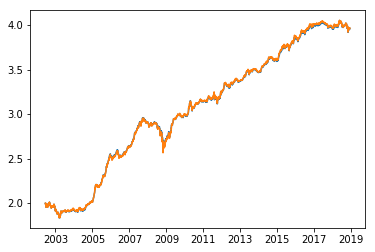

In [8]:
plt.plot(레포트1["날짜"], np.log10(레포트1["누적수익률(%)"] + 100))
plt.plot(레포트2["날짜"], np.log10(레포트2["누적수익률(%)"] + 100))

plt.show()